In [14]:
import numpy as np
import os
import sys
sys.path.append('../')
from utils.ResultsEvaluation import ResultsEvaluation
from utils.graph_plot import *

In [15]:
thresholds = np.arange(1,10)
tres = []

for t in thresholds:
    tres.append(ResultsEvaluation(f'threshold/default_{t}_evaluations.json'))
    

In [23]:
tres_arr = []
for t in tres:
    tres_arr.append(np.array(t.per_run_f1_score))

### Logica dell’ANOVA:

- calcola la variazione totale dei valori di BA
- divide la variazione in:
    - variazione tra i gruppi
    - variazione dentro i gruppi
    - confronta i due tipi di variazione.

Interpretazione:

se i threshold sono diversi → la variazione tra gruppi dovrebbe essere grande

se i threshold sono simili → la variazione tra gruppi sarà piccolissima

## Confronto statistico tra threshold

Per verificare se i diversi valori di threshold producono variazioni reali nella balanced accuracy, ho confrontato le rispettive distribuzioni tramite due test statistici:

### ANOVA unidirezionale

L’ANOVA confronta la media di più gruppi valutando quanta variabilità è spiegata dalle differenze tra gruppi rispetto alla variabilità interna.
È adatto quando si vuole verificare se almeno un threshold genera una performance media significativamente diversa dagli altri.

### Kruskal–Wallis

Il test di Kruskal–Wallis è la versione non parametrica dell’ANOVA.
Confronta la posizione dei ranghi delle osservazioni, senza assumere normalità o varianze omogenee.
È utile come controllo robusto, perché non dipende dalla forma delle distribuzioni.

In [24]:
import numpy as np
from scipy.stats import f_oneway, kruskal
from itertools import combinations

flat = [arr.flatten() for arr in tres_arr]

# Test ANOVA parametrico
anova_stat, anova_p = f_oneway(*flat)
print("ANOVA p-value:", anova_p)

# Test Kruskal-Wallis (non parametrico)
kw_stat, kw_p = kruskal(*flat)
print("Kruskal-Wallis p-value:", kw_p)

ANOVA p-value: 0.999875044411463
Kruskal-Wallis p-value: 0.9999554610011844


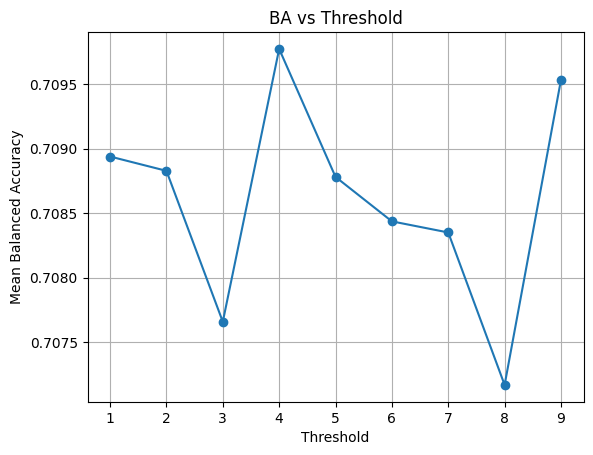

In [18]:
means = [arr.mean() for arr in tres_arr]

plt.plot(thresholds, means, marker='o')
plt.xlabel('Threshold')
plt.ylabel('Mean Balanced Accuracy')
plt.title('BA vs Threshold')
plt.grid(True)

### Accuracy graphs

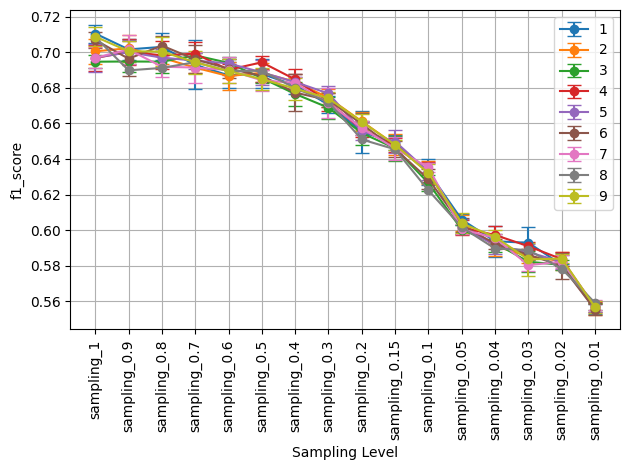

In [22]:
for t,tre in zip(thresholds,tres):
    plot_per_run_metric(tre, attr_name='per_run_f1_score', metric_name=t)

In [20]:
res = []
for t, tre in zip(thresholds, tres):
    a = np.mean(np.mean(np.array(tre.per_run_balanced_accuracy), axis = 0), axis = 1)
    res.append(a)
    
stacked = np.stack(res)  # shape: (2, 16)
winners = np.argmax(stacked, axis=0)

for sample in winners:
    print(f'The best sampling division is {sample}')

The best sampling division is 8
The best sampling division is 0
The best sampling division is 5
The best sampling division is 3
The best sampling division is 2
The best sampling division is 3
The best sampling division is 3
The best sampling division is 4
The best sampling division is 8
The best sampling division is 8
The best sampling division is 6
The best sampling division is 7
The best sampling division is 3
The best sampling division is 0
The best sampling division is 1
The best sampling division is 7


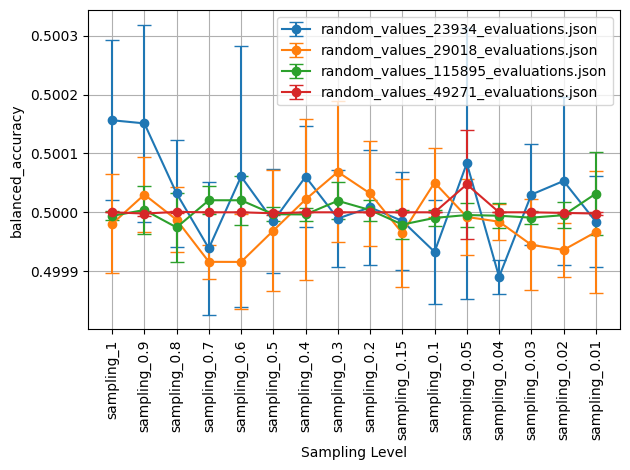

In [21]:
randoms = os.listdir('../results/random/')
for r in randoms:
    plot_per_run_metric(ResultsEvaluation(f'random/{r}'), attr_name='per_run_balanced_accuracy', metric_name=r)